# 02_EDA: ds002778 — Resting State EEG

**Author:** Fajar Laksono

**Dataset:** UC San Diego Resting State EEG — Parkinson's Disease vs. Healthy Controls  
**Source:** https://openneuro.org/datasets/ds002778  
**Format:** BIDS / BioSemi `.bdf`

## 1. Overview
### 1.1. Top-level Files
| File | Description |
|------|-------------|
| dataset_description.json | Study Name, Autors, DOI (Digital Object Identifier), License |
| participants.tsv | One row per subject - Demographics + Clinical Scores |
| participants.json | Column definitions for participants.tsv |
| task-rest_beh.json | Behavioral sidecar (dummy - no actual trials) |
| CHANGES, README | Changelog and study notes |

### 1.2. Participants (tsv, json)
| Column | Description |
|--------|-------------|
| participant_id | `sub-hc` = healthy control, `sub-pd` Parkinson | 
| age | Age in years | 
| gender | f/m |
| hand | Handedness (all right-handed) |
| MMSE | Mini-Mental State Exam - cognitive screen (>24 = normal, all subjects normal) |
| NAART | IQ-proxy score (North American Adult Reading Test) | 
| disease_duration | Years since PD diagnosis (HC = NaN) |
| rl_deficits | Which body side is worse (PD only) |
| notes | Experimenter notes (sub-pd6, sub-pd16 used preprocessed EEGLAB data for ses-on) |

### 1.3. Per-subject folder structure

&emsp; sub-{id}/  
&emsp;&emsp; ses-{hc|off|on}/  
&emsp;&emsp;&emsp; sub-{id}_ses-{...}_scans.tsv &emsp;&emsp;&emsp;&emsp; acquisition timestamp  
&emsp;&emsp;&emsp; beh/  
&emsp;&emsp;&emsp;&emsp; *_beh.tsv &emsp;&emsp;&emsp;&emsp; dummy file (no behavioural data)  
&emsp;&emsp;&emsp; eeg/  
&emsp;&emsp;&emsp;&emsp; *_eeg.bdf &emsp;&emsp;&emsp;&emsp; ← THE SIGNAL &emsp;&emsp; ~11 MB, 512 Hz, ~192 s  
&emsp;&emsp;&emsp;&emsp; *_eeg.json &emsp;&emsp;&emsp;&emsp; recording metadata (manufacturer, sfreq, etc.)  
&emsp;&emsp;&emsp;&emsp; *_channels.tsv &emsp;&emsp;&emsp;&emsp; channel names, types, status  
&emsp;&emsp;&emsp;&emsp; *_events.tsv &emsp;&emsp;&emsp;&emsp; trigger markers (start + 1 event)  

### 1.4. EEG channels
EEG or Electroencephalography is non-invasive monitoring method used in neuroscience to record the electrical activity of the brain. It detects the synchronized activity of million of neurons, which create small electrical voltage fluctuation. How it works: Neurons communicates trhough electrical impulses. When a large group of neurons fires together, they create an electric field strong enough to be detected through the skull.

| Channels | Type |
|----------|------|
| Fp1, AF3, F7 ... Fz, Cz | EEG (10-20 system) |
| EXG1-EXG8 | External (EOG / reference) |
| Status | Trigger/TRIG |

### 1.5. Sessions per group
| Group | Session | n |
|-------|---------|---|
| Healthy Controls | `ses-hc` | 16 |
| Parkinson's Disease (meds OFF) | `ses-off` | 15 |
| Parkinson's Disease (meds ON) | `ses-on` | 15 |


## 2. Preparations

### 2.1. Libraries

In [105]:
# Import libraries
import os, json as _json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import mne_bids
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals
import warnings

# Display the versions of the libraries used
print(f"Python version: {os.sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"mne version: {mne.__version__}")
print(f"mne_bids version: {mne_bids.__version__}")

Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
pandas version: 2.2.3
numpy version: 2.2.4
matplotlib version: 3.10.3
mne version: 1.11.0
mne_bids version: 0.18.0


### 2.2. Configurations

In [106]:
# Log settings
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore', message='Unable to map the following column', category=RuntimeWarning)

# BIDS root directory settings
BIDS_ROOT = os.path.join('datasets', 'ds002778')
print(f'BIDS root: {os.path.abspath(BIDS_ROOT)}')

BIDS root: D:\Project\Github\FajarLaksono\ai-neuro-EEG-ds002778-analysis\datasets\ds002778


## 3. Load Datasets
### 3.1. BIDS Metadata

BIDS metadata is a standardized set of information, typically stored in JSON "sidecar" files, that describes neuroimaging data (MRI=Magnetic Reasonance Imaging, EEG=Electroencephalography, MEG=Magnetoencephalography) for improved FAIR compliance (Findable, Accessible, Interoperable, Reusable). It includes essential parameters like scan parameters, subject details, and task information to enable automated, reproducible analysis across different software tools.

#### 3.1.1. Print Dataset Description

In [107]:
#load dataset description
dataset_description_path = os.path.join(BIDS_ROOT, 'dataset_description.json')
print(f"Dataset description path: {os.path.abspath(dataset_description_path)}")

dataset_description = "{}"

with open(dataset_description_path) as f:
    dataset_description = _json.load(f)
    
print(_json.dumps(dataset_description, indent=2))


Dataset description path: D:\Project\Github\FajarLaksono\ai-neuro-EEG-ds002778-analysis\datasets\ds002778\dataset_description.json
{
  "Name": "UC San Diego Resting State EEG Data from Patients with Parkinson's Disease",
  "BIDSVersion": "1.2.2",
  "Authors": [
    "Alexander P. Rockhill",
    "Nicko Jackson",
    "Jobi George",
    "Adam Aron",
    "Nicole C. Swann"
  ],
  "DatasetDOI": "doi:10.18112/openneuro.ds002778.v1.0.5",
  "License": "CC0"
}


#### 3.1.2. Load Participant Metadata

In [108]:
# Load participants information
participants_path = os.path.join(BIDS_ROOT, 'participants.tsv')
print(f"Participants file path: {os.path.abspath(participants_path)}")

participants = pd.read_csv(participants_path, sep='\t')

# Derive group from subject ID prefix between PD and HC
participants['group'] = participants['participant_id'].apply(
    lambda x: 'PD' if 'pd' in x.lower() else 'HC'
)
print(f'Subjects: {len(participants)}  |  HC: {(participants.group=="HC").sum()}  |  PD: {(participants.group=="PD").sum()}')
display(participants)

Participants file path: D:\Project\Github\FajarLaksono\ai-neuro-EEG-ds002778-analysis\datasets\ds002778\participants.tsv
Subjects: 31  |  HC: 16  |  PD: 15


,participant_id,age,gender,hand,MMSE,NAART,disease_duration,rl_deficits,notes,group
0,sub-hc1,54,f,r,30,48,NaN,NaN,NaN,HC
1,sub-hc2,50,f,r,30,55,NaN,NaN,NaN,HC
2,sub-pd3,52,f,r,29,44,9.0,R,NaN,PD
3,sub-hc4,50,f,r,30,52,NaN,NaN,NaN,HC
4,sub-pd5,67,f,r,29,48,2.0,"No clear side, perhaps more L",NaN,PD
5,sub-pd6,62,f,r,30,42,8.0,"L OFF meds, more R ON meds",Used preprocessed data from EEGLAB .mat file i...,PD
6,sub-hc7,54,f,r,26,48,NaN,NaN,NaN,HC
7,sub-hc8,71,f,r,29,41,NaN,NaN,NaN,HC
8,sub-pd9,55,f,r,28,50,12.0,R,NaN,PD
9,sub-hc10,59,f,r,29,51,NaN,NaN,NaN,HC


### 3.2. Load Raw EEG — One Subject

List all subjects in the BIDS dataset, Split into Healthy Control (HC) and Parkinson’s Disease (PD) groups, Pick the first HC subject, and Load their resting-state EEG data into memory as an MNE Raw object for further analysis.

In [109]:
# Crawl and List subjects in BIDS directory and separate by group (for any directory or file starting with the prefix sub-)
subjects = get_entity_vals(BIDS_ROOT, 'subject')
print(f'Subjects found in BIDS directory: {subjects}')
hc_subs = [s for s in subjects if 'hc' in s.lower()]
pd_subs = [s for s in subjects if 'pd' in s.lower()]
print(f'HC: {hc_subs}')
print(f'PD: {pd_subs}')

# Load first HC subject for overview
subject = hc_subs[0]
print(f'\nLoading: sub-{subject}, ses-hc')
bids_path = BIDSPath(subject=subject, session='hc', task='rest', datatype='eeg', root=BIDS_ROOT)
raw = read_raw_bids(bids_path, verbose=False)
raw.load_data()

# EXG1-8 are external (EOG/reference) channels typed as 'eeg' by default.
# Retype them as 'misc' so they are excluded from EEG topomap plots.
exg_chs = {ch: 'misc' for ch in raw.ch_names if ch.startswith('EXG')}
raw.set_channel_types(exg_chs)

# BioSemi .bdf files don't embed electrode positions — set from standard montage.
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')

Subjects found in BIDS directory: ['hc1', 'hc10', 'hc18', 'hc2', 'hc20', 'hc21', 'hc24', 'hc25', 'hc29', 'hc30', 'hc31', 'hc32', 'hc33', 'hc4', 'hc7', 'hc8', 'pd11', 'pd12', 'pd13', 'pd14', 'pd16', 'pd17', 'pd19', 'pd22', 'pd23', 'pd26', 'pd28', 'pd3', 'pd5', 'pd6', 'pd9']
HC: ['hc1', 'hc10', 'hc18', 'hc2', 'hc20', 'hc21', 'hc24', 'hc25', 'hc29', 'hc30', 'hc31', 'hc32', 'hc33', 'hc4', 'hc7', 'hc8']
PD: ['pd11', 'pd12', 'pd13', 'pd14', 'pd16', 'pd17', 'pd19', 'pd22', 'pd23', 'pd26', 'pd28', 'pd3', 'pd5', 'pd6', 'pd9']

Loading: sub-hc1, ses-hc


C:\Users\User\AppData\Local\Temp\ipykernel_15992\50385366.py:19: RuntimeWarning: The unit for channel(s) EXG1, EXG2, EXG3, EXG4, EXG5, EXG6, EXG7, EXG8 has changed from V to NA.
  raw.set_channel_types(exg_chs)


<RawBDF | sub-hc1_ses-hc_task-rest_eeg.bdf, 41 x 98304 (192.0 s), ~30.8 MiB, data loaded>

## 4. Analysis
We will learn the data distribution and the details of one sample that was picked above "hc_subs[0]".

### 4.1. Demographic Distribution
#### 4.1.1. Visualization of Demographic Distribution
This code produces two side-by-side histograms:
- Age distribution of HC vs PD
- MMSE score distribution of HC vs PD

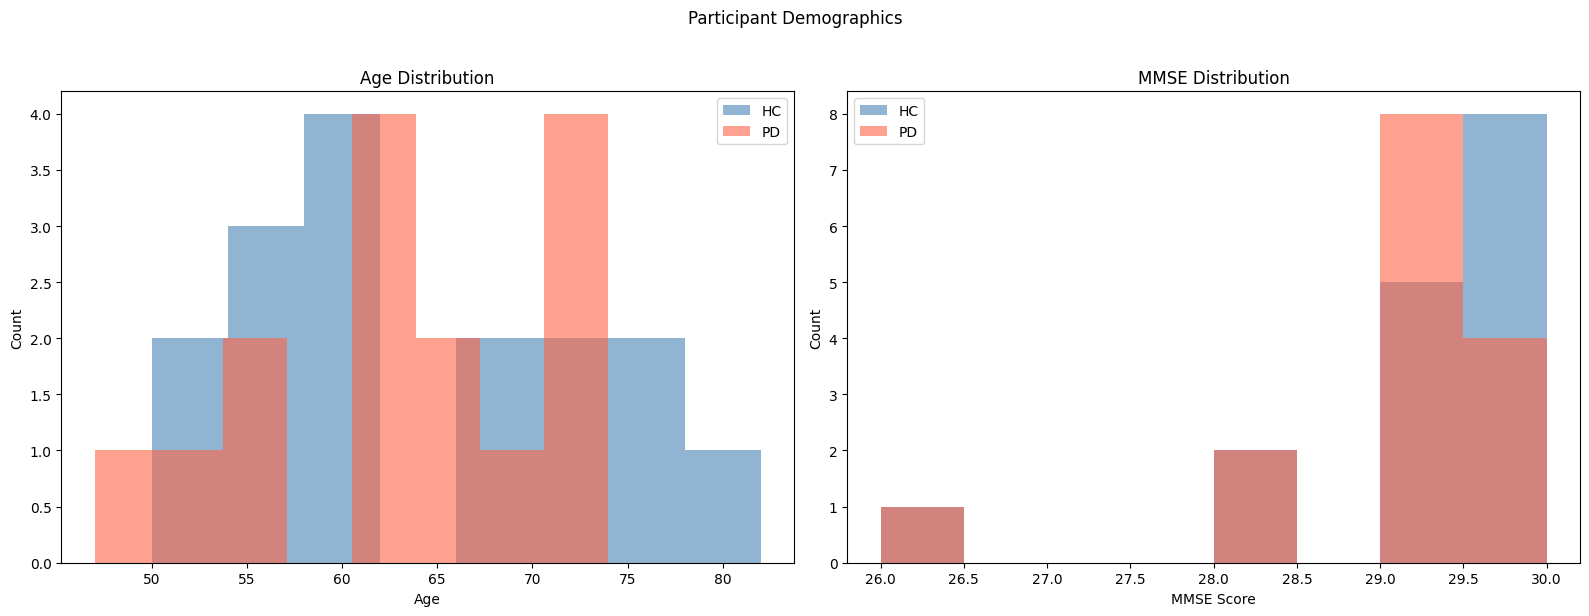

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution
for grp, color in [('HC', 'steelblue'), ('PD', 'tomato')]:
    axes[0].hist(participants[participants.group==grp]['age'].dropna(),
                 bins=8, alpha=0.6, label=grp, color=color)
    
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution'); axes[0].legend()

# MMSE score
for grp, color in [('HC', 'steelblue'), ('PD', 'tomato')]:
    axes[1].hist(participants[participants.group==grp]['MMSE'].dropna(),
                 bins=8, alpha=0.6, label=grp, color=color)
axes[1].set_xlabel('MMSE Score'); axes[1].set_ylabel('Count')
axes[1].set_title('MMSE Distribution'); axes[1].legend()

plt.suptitle('Participant Demographics', y=1.02)
plt.tight_layout()
plt.show()

#### 4.1.2. Summary of Demographic Distribution
- The visualization compares Healthy Control (HC) and Parkinson’s Disease (PD) groups across age and cognitive performance. 
- The Age Distribution shows a balanced, multi-modal spread between 50 and 80 years, suggesting the two groups are relatively well-matched by age to minimize it as a confounding variable. - The MMSE Distribution (Mini-Mental State Examination) reveals that both groups are high-functioning, with most scores clustered between 29 and 30. 
- However, the PD group (red) shows a slight negative skew with a few lower scores down to 26, whereas the HC group (blue) is more strictly concentrated at the ceiling of the scale (30). - Overall, the participants appear to be cognitively stable older adults, making this a baseline comparison of groups with similar demographic and cognitive profiles.

### 4.2. Signal Properties
#### 4.2.1. Information of Signal Properties
In this step, I am extracting the core metadata from the raw EEG recording to verify the signal's properties. By inspecting the info structure, I can confirm essential parameters such as the sampling rate, the total duration of the session, and the specific electrode configuration (channel names). This ensures the data has loaded correctly and matches the expected experimental design before proceeding to preprocessing.

In [111]:
print(raw.info)
print(f"\nSampling rate : {raw.info['sfreq']} Hz")
print(f"Duration      : {raw.times[-1]:.1f} s  ({raw.times[-1]/60:.1f} min)")
print(f"Channels      : {len(raw.ch_names)}")
print(f"Channel names : {raw.ch_names}")

<Info | 12 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 8 misc, 1 Stimulus
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 35 items (3 Cardinal, 32 EEG)
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 104.0 Hz
 meas_date: 2011-01-19 04:22:56 UTC
 nchan: 41
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: sub-hc1, birthday: 1957-01-18, hand: 1>
>

Sampling rate : 512.0 Hz
Duration      : 192.0 s  (3.2 min)
Channels      : 41
Channel names : ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


#### 4.2.2. Summary of Signal Properties
You can break down the output into these key technical highlights:
- Sampling Rate ($512.0$ Hz): This means the device recorded data points 512 times per second. This is a solid resolution for capturing standard brain wave frequencies.
- Duration ($192.0$ seconds): The recording lasts exactly 3.2 minutes.
- Channel Composition: There are 41 channels in total. The breakdown is:
- 40 EEG channels: These are the electrodes placed on the scalp (labeled like 'Fp1', 'Cz', etc.).
- 1 Stimulus/Status channel: This is used to mark exactly when a stimulus (like a sound or image) occurred during the experiment.
- Filter Settings: The lowpass is at $104.0$ Hz and highpass is at $0.0$ Hz, meaning the data is currently "raw" and hasn't been filtered to remove low-frequency drift or high-frequency noise yet.
- Subject Info: The data belongs to a subject born in 1957, and the recording was anonymized to protect their privacy.

### 4.3. Raw EEG Traces
#### 4.3.1. Visualization of Raw EEG Traces
This step renders a scrollable time-series view of the raw, unfiltered EEG signal for the first 20 channels over the first 10 seconds. Inspecting the raw traces allows us to visually assess signal quality, spot obvious artefacts (e.g., sudden large-amplitude jumps, flat lines, or muscle noise), and gain intuition for typical amplitude ranges and low-frequency drift before any cleaning is applied.

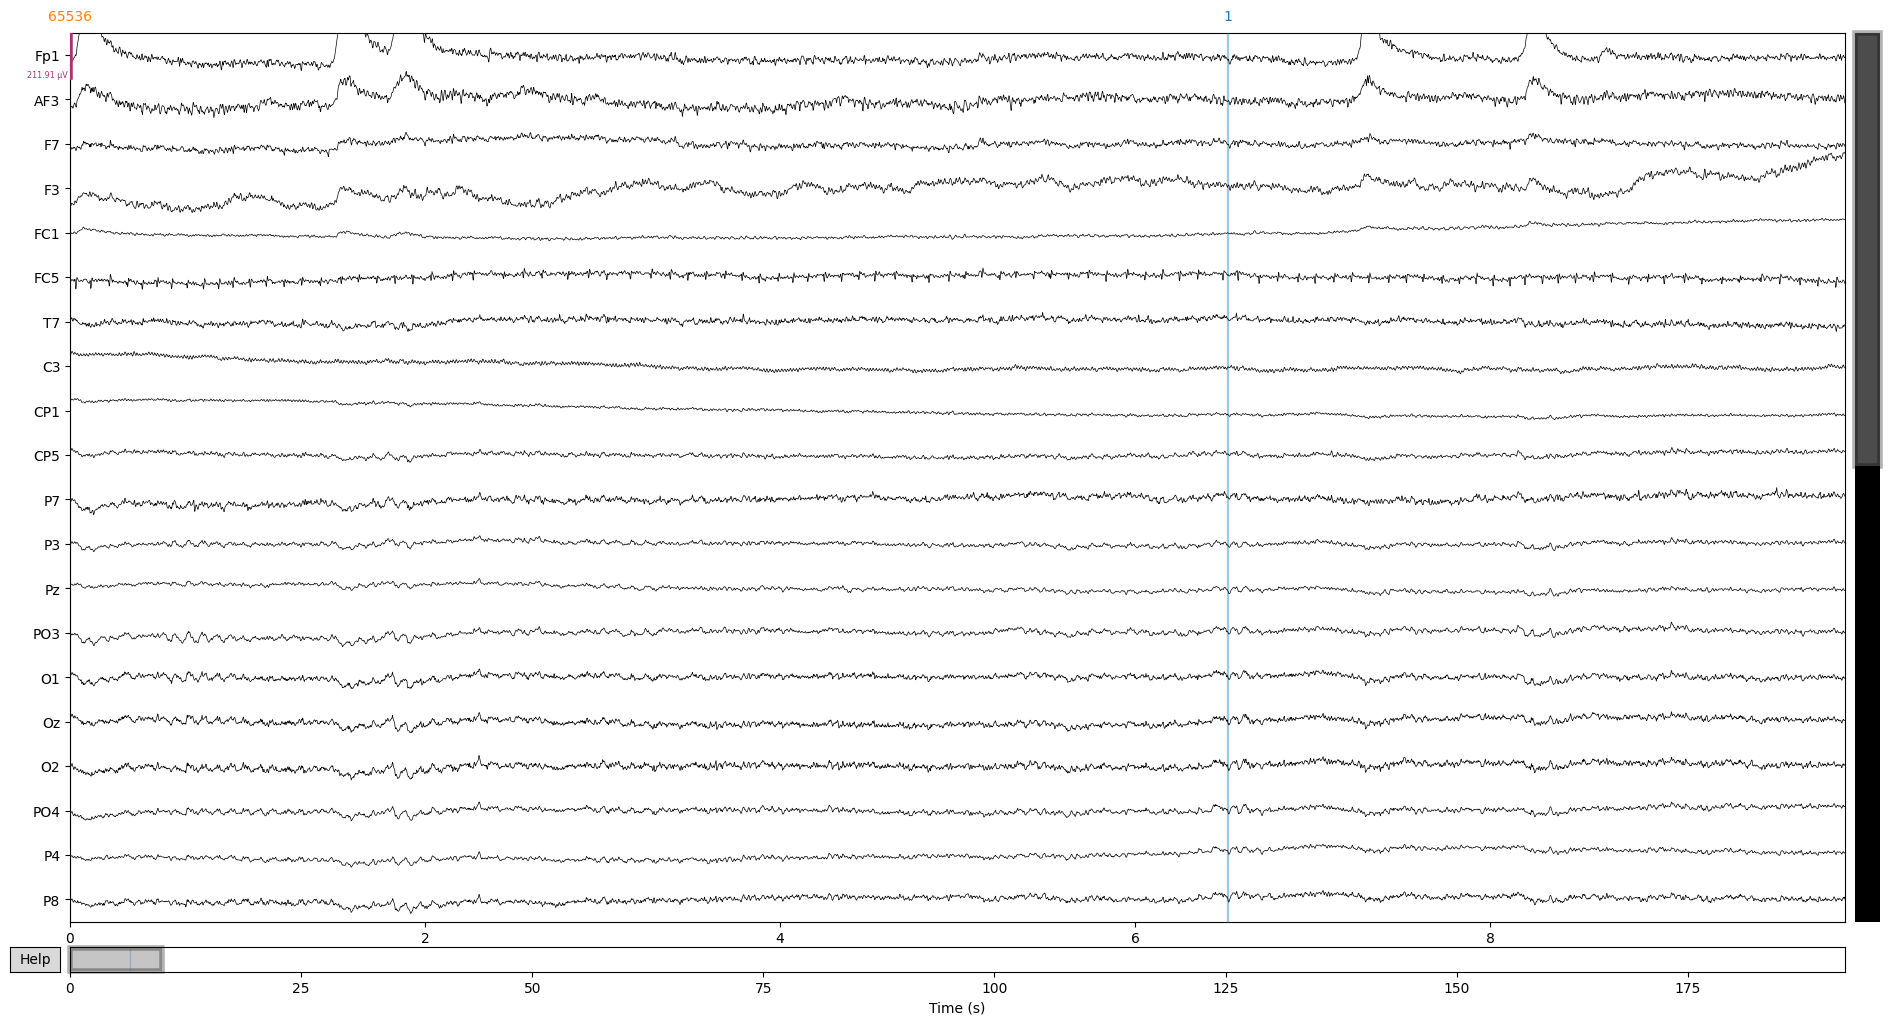

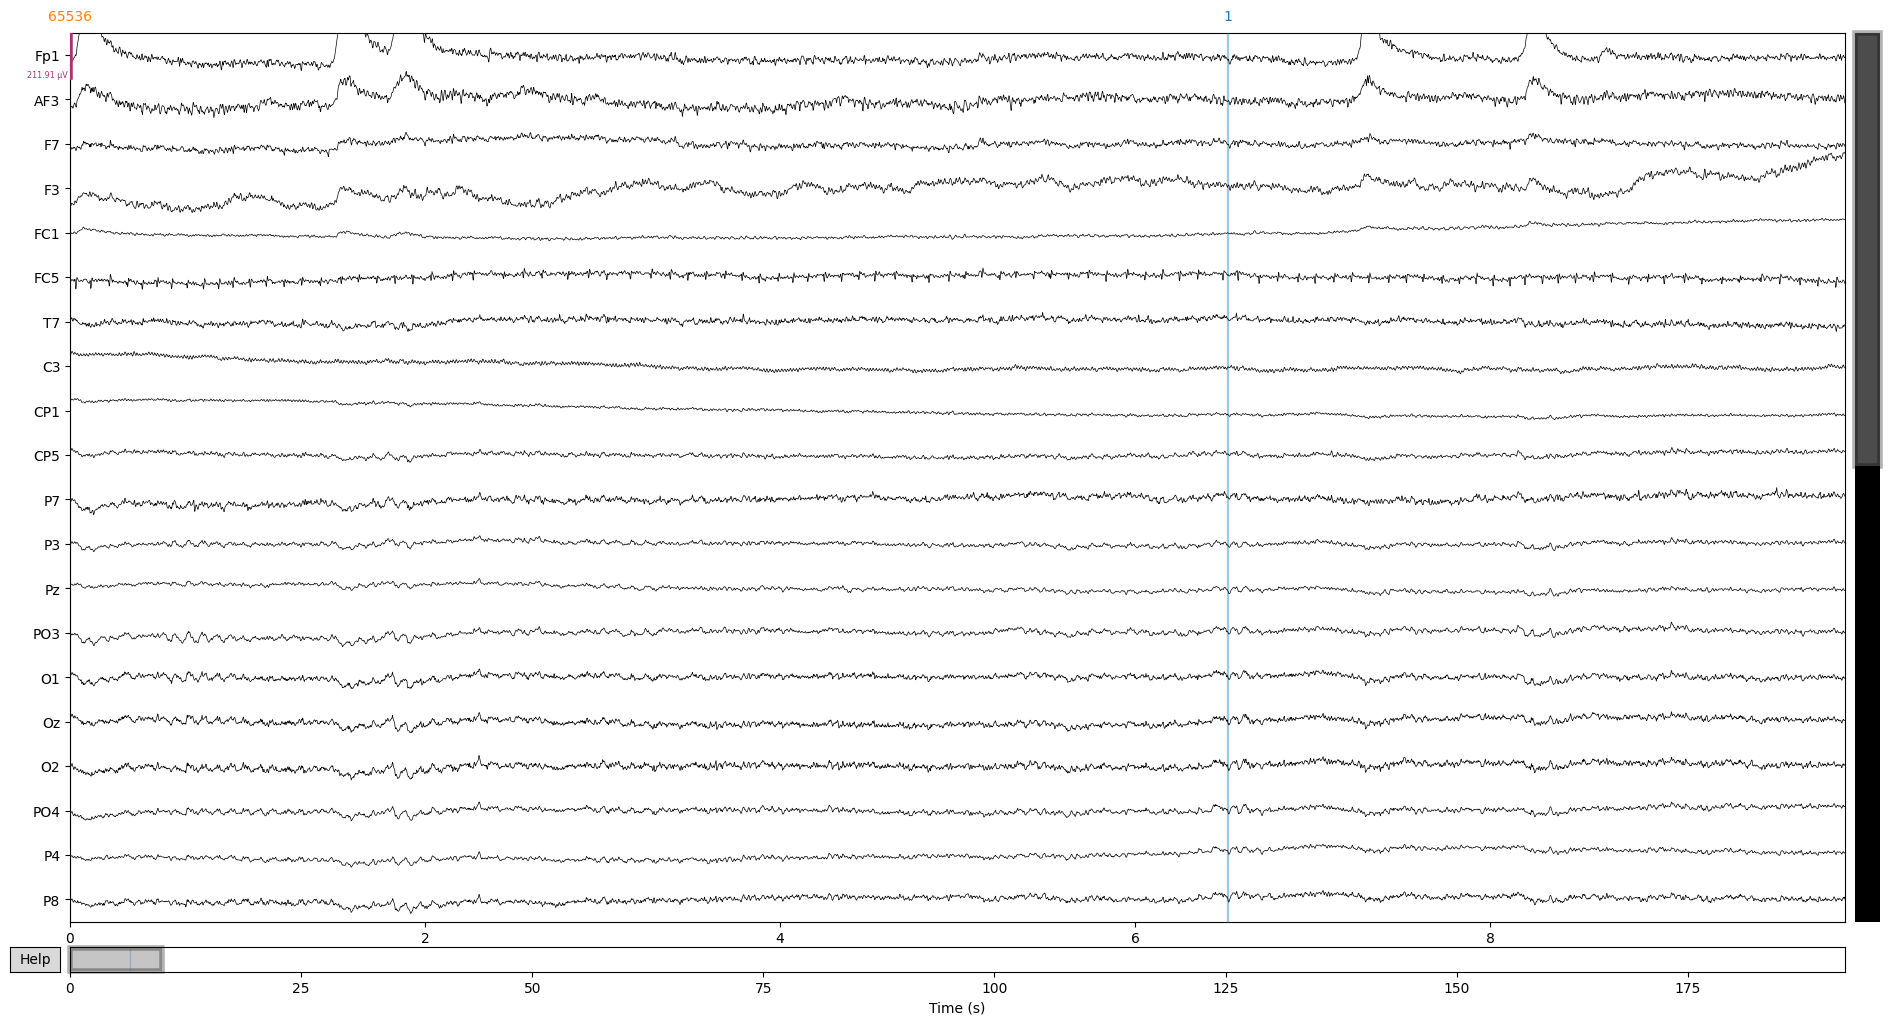

In [112]:
# %matplotlib qt

raw.plot(
    duration=10, n_channels=20, scalings='auto',
    title=f'Raw EEG — sub-{subject} ses-hc (first 10 s)',
    show=True
)

# %matplotlib inline

#### 4.3.2. Summary of Raw EEG Traces
- The raw traces for the list 10 seconds across 20 channels reveal a signal that is generally intact but heavily influenced by environmental and biological artifact.
- The X-axis (Time): Each  panel shows a window of time. Horizontal "waves" represent the electrical activity at each electrode.
- The Y-axis (Amplitude): The vertical spikes or "wiggles" shows the strength of the signal. In EEG, we look for scale --if one channel is much "taller" than others, it's often an artifact.
- Low-frequency Drift: Notice how some lines aren't straight but "wander" up and down slowly, that is electrode polarization or movement, which we'll remove later with a high-pass filter
- High-frequency "Fuzz": The tickeness of the lines indicates high-frequency noise.
- Signal Integrity: No "flat-line" channels or extreme "rail-to-rail" saturation, where the signal hits the to/bottom of the range, are immediately evident, indicating all electrodes were recording.
- Bioligical Artifacts: Prominent, High-amplitude, slow-wave deflections are visible in the frontal channels (top of the traces), which are characteristic of eye blinks and vertical eye movements.
- Technical Artifacts: There is significant low-frequency drift across multiple channels, where the baseline "wander" over time. Additionally, a consistent high-frequency "fuzz" or thickening of the trace lines is visible, corroborating the 60 Hz power-line interferences and ~36 Hz noise identified in the PSD analysis.
- Conclusion: The raw data is of sufficient quality for further processing, but requires aggressive high-pass filtering to remove drift and notch filtering to address the identified narrow-band noise.
- If you look closely at the bottom-left and bottom-right panels of your grid, you can see some periodic, rhythmic activity. Some of that might be your alpha rhythm appearing in time, but the very sharp, consistent "spikes" occurring regularly are often ECG (heartbeat) artifacts or pulse artifacts bleeding into the EEG electrodes.

### 4.4. Power Spectral Density (Single Subject: Sub-hc1)
#### 4.4.1. Visualization of Power Spectral Density (PSD)
Welch's method is applied to estimate the Power Spectral Density (PSD) of the raw EEG signal, averaged across all 32 EEG channels. The PSD transforms the time-domain signal into the frequency domain, revealing which oscillatory frequencies dominate the resting-state recording. A clean EEG should exhibit the characteristic 1/f power decay (power decreasing with increasing frequency) and a distinct alpha peak around 8–13 Hz — a hallmark of relaxed wakefulness.

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


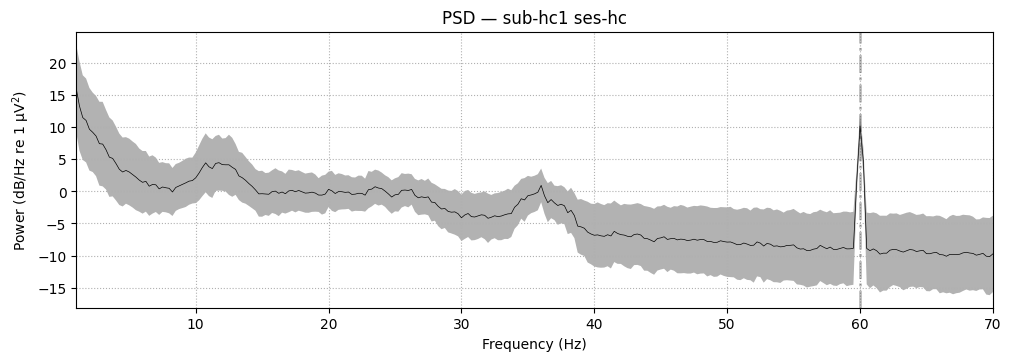

In [113]:
spectrum = raw.compute_psd(method='welch', fmin=1, fmax=70, n_fft=2048)
spectrum.plot(average=True, picks='eeg')
plt.title(f'PSD — sub-{subject} ses-hc')
plt.show()

#### 4.4.2. Summary of Power Spectral Density (PSD)
The Power Spectral Density (PSD) analysis reveals the following key characteristics:
- 1/f Spectral Trend: The signal exhibit the expected 1/f power decay, where power is highest at lower frequencies and generally trends downward. However, this decrease is not strictly monotonic due to several distinct oscillatory peaks and artifacts.
- Alpha Band (8-13 Hz): there is visible activity in the alpha band (8–13 Hz), it presents as a broad elevation rather than a sharp, singular peak.
- A sharp, narrow-band spike at 60 Hz, confirming high-magnitude US power-line interference. This necessitates the use of a 60 Hz notch filter during preprocessing.
- An anomalous spike at ~36 Hz, which is not typical of biological resting-state EEG and suggests secondary equipment interference or a mechanical artifact.
- Overall, while the underlying $1/f$ trend is healthy, the presence of these two distinct spikes indicates that further noise attenuation is required before proceeding with feature extraction.

### 4.5. Channel Topography
#### 4.5.1. Glossary of Channel Topography 
##### 4.5.1.1. Frequency bands

| Band | Range | Relevance | Associated With |
|------|-------|-----------|-----------------|
| Delta | 1–4 Hz | Cortical slowing in PD | Deep sleep, unconscious processes |
| Theta | 4–8 Hz | Memory / cognitive | Drowsiness, memory, meditation |
| Alpha | 8–13 Hz | Idling rhythm, visual cortex | Relaxed wakefulness, eyes closed, idle cortex |
| Beta | 13–30 Hz | Motor / basal ganglia synchrony | Active thinking, motor control, alertness |
| Gamma | 30–40 Hz | High-frequency processing | High-level cognition, sensory binding |

##### 4.5.1.2. ROI (Region of Interest)  
| ROI | Channels | Brain Area |
|-----|----------|------------|
| Frontal | Fp1, Fp2, AF3, AF4, F7, F3, Fz, F4, F8 | Prefrontal & frontal lobe — cognition, executive function |
| Central | FC1, FC2, FC5, FC6, C3, Cz, C4 | Motor cortex — movement control (key for PD) | 
| Parietal | CP1, CP2, CP5, CP6, P3, Pz, P4, P7, P8 | Sensorimotor integration, spatial processing |
| Occipital | O1, Oz, O2, PO3, PO4 | Visual cortex — where alpha is strongest at rest |

#### 4.5.2. Visualization of Channel Topography
Two spatial visualisations are produced here. First, `plot_sensors` renders a 2D projection of the 32 electrode positions onto a circular scalp model, confirming the standard 10-20 montage layout and bilateral hemisphere coverage. Second, `spectrum.plot_topomap` maps the mean spectral power within three canonical frequency bands — Delta (1–4 Hz), Alpha (8–13 Hz), and Beta (13–30 Hz) — across the scalp surface using colour interpolation, revealing where in the brain each oscillatory rhythm is strongest during rest.

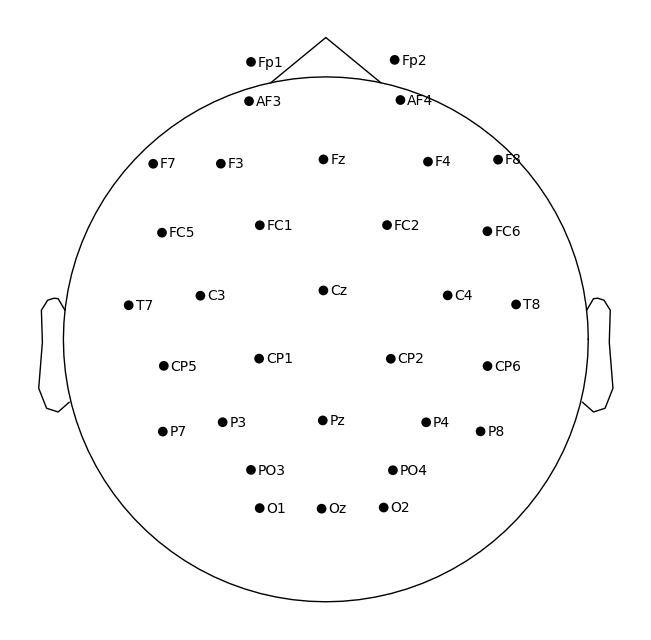

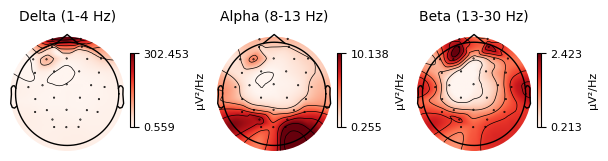

In [114]:
raw.plot_sensors(show_names=True, title=f'Channel Layout — sub-{subject}')
plt.show()

spectrum.plot_topomap(bands={'Delta (1-4 Hz)': (1,4), 'Alpha (8-13 Hz)': (8,13), 'Beta (13-30 Hz)': (13,30)})
plt.show()

#### 4.5.3. Summary of Topography
The sensor plot confirms the standard 10-20 layout with 32 electrodes distributed across frontal (Fp1/2, AF3/4, F-series), central (FC, C, CP-series), parietal (P-series, PO), and occipital (O1/2, Oz) regions, providing good whole-scalp coverage.

The power topomaps reveal the expected spatial distribution for a resting-state EEG:
- **Delta (1–4 Hz)**: Broadly distributed with a slight frontal bias, partly reflecting low-frequency drift and ocular artefact contributions that remain in the unfiltered signal.
- **Alpha (8–13 Hz)**: Strongest over the posterior parietal and occipital regions (Oz, O1/2, PO3/4), which is the canonical resting-state alpha signature generated by visual cortex during relaxed wakefulness.
- **Beta (13–30 Hz)**: More anteriorly distributed, concentrated over frontal and central regions, consistent with sensorimotor activity at rest.

### 4.6. Group-Level PSD: HC vs PD-off vs PD-on

This section computes and visualises the channel-averaged PSD for all 46 recordings across three conditions:
- `HC` — 16 healthy controls (`ses-hc`)
- `PD-off` — 15 Parkinson's patients, medication OFF (`ses-off`)
- `PD-on` — 15 Parkinson's patients, medication ON (`ses-on`)

Each subject's PSD is averaged across channels and then plotted as a group mean ± SEM ribbon. This group-level comparison addresses the central exploratory question of the EDA: 
- do the spectral profiles of PD patients differ from healthy controls? 
- does levodopa medication produce a measurable change in resting-state neural oscillations?

TLDR: 
- Sick vs. Healthy: Is there a visible difference in brain waves between people with Parkinson’s and healthy people?
- Meds vs. No Meds: Does taking Parkinson’s medication actually fix or change those brain wave patterns?

#### 4.6.1. Calculation of PSD: HC vs PD-off vs PD-on

In [115]:
FMIN, FMAX = 1, 70

# Map: group_label -> list of (subject, session)
to_load = (
    [('HC',     s, 'hc')  for s in hc_subs] +
    [('PD-off', s, 'off') for s in pd_subs] +
    [('PD-on',  s, 'on')  for s in pd_subs]
)

group_psds = {'HC': [], 'PD-off': [], 'PD-on': []}
freqs_ref = None

for grp, sub, ses in to_load:
    try:
        bp = BIDSPath(subject=sub, session=ses, task='rest', datatype='eeg', root=BIDS_ROOT)
        r = read_raw_bids(bp, verbose=False).load_data()
        psd = r.compute_psd(method='welch', fmin=FMIN, fmax=FMAX, n_fft=2048)
        psd_data, freqs = psd.get_data(return_freqs=True)
        group_psds[grp].append(psd_data.mean(axis=0))  # average over channels
        if freqs_ref is None:
            freqs_ref = freqs
        print(f'  sub-{sub} ses-{ses} ({grp}) OK')
    except Exception as e:
        print(f'  sub-{sub} ses-{ses} skipped: {e}')

print('Done.')

  sub-hc1 ses-hc (HC) OK
  sub-hc10 ses-hc (HC) OK
  sub-hc18 ses-hc (HC) OK
  sub-hc2 ses-hc (HC) OK
  sub-hc20 ses-hc (HC) OK
  sub-hc21 ses-hc (HC) OK
  sub-hc24 ses-hc (HC) OK
  sub-hc25 ses-hc (HC) OK
  sub-hc29 ses-hc (HC) OK
  sub-hc30 ses-hc (HC) OK
  sub-hc31 ses-hc (HC) OK
  sub-hc32 ses-hc (HC) OK
  sub-hc33 ses-hc (HC) OK
  sub-hc4 ses-hc (HC) OK
  sub-hc7 ses-hc (HC) OK
  sub-hc8 ses-hc (HC) OK
  sub-pd11 ses-off (PD-off) OK
  sub-pd12 ses-off (PD-off) OK
  sub-pd13 ses-off (PD-off) OK
  sub-pd14 ses-off (PD-off) OK
  sub-pd16 ses-off (PD-off) OK
  sub-pd17 ses-off (PD-off) OK
  sub-pd19 ses-off (PD-off) OK
  sub-pd22 ses-off (PD-off) OK
  sub-pd23 ses-off (PD-off) OK
  sub-pd26 ses-off (PD-off) OK
  sub-pd28 ses-off (PD-off) OK
  sub-pd3 ses-off (PD-off) OK
  sub-pd5 ses-off (PD-off) OK
  sub-pd6 ses-off (PD-off) OK
  sub-pd9 ses-off (PD-off) OK
  sub-pd11 ses-on (PD-on) OK
  sub-pd12 ses-on (PD-on) OK
  sub-pd13 ses-on (PD-on) OK
  sub-pd14 ses-on (PD-on) OK
  sub-pd16 s

#### 4.6.2. Visualizations of PSD: HC vs PD-off vs PD-on

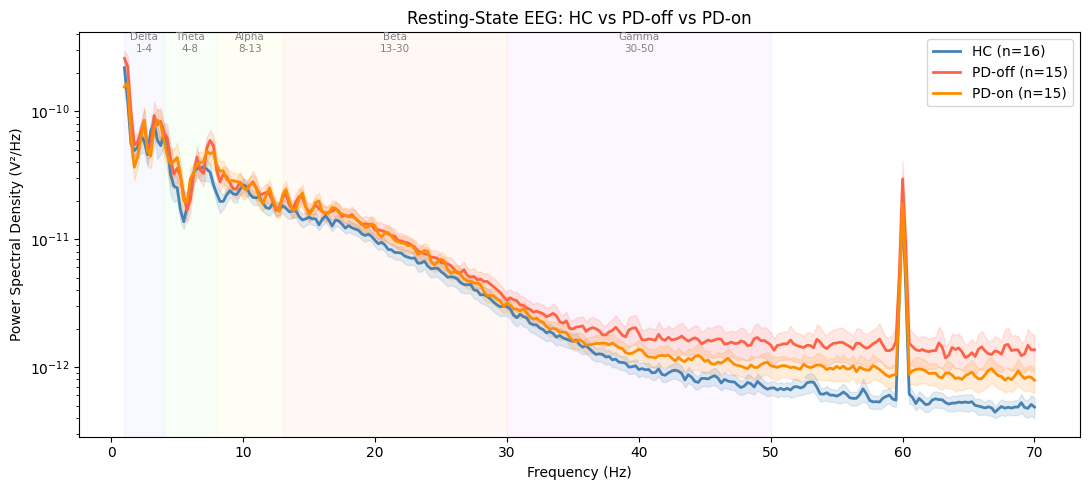

In [116]:
GROUPS = {
    'HC':     'steelblue',
    'PD-off': 'tomato',
    'PD-on':  'darkorange',
}

fig, ax = plt.subplots(figsize=(11, 5))

for grp, color in GROUPS.items():
    arr = np.array(group_psds[grp])
    mean_psd = arr.mean(axis=0)
    sem_psd  = arr.std(axis=0) / np.sqrt(len(arr))
    ax.semilogy(freqs_ref, mean_psd, color=color, lw=2, label=f'{grp} (n={len(arr)})')
    ax.fill_between(freqs_ref, mean_psd - sem_psd, mean_psd + sem_psd, alpha=0.15, color=color)

# Frequency band shading
bands = [('Delta\n1-4', 1, 4), ('Theta\n4-8', 4, 8),
         ('Alpha\n8-13', 8, 13), ('Beta\n13-30', 13, 30), ('Gamma\n30-50', 30, 50)]
band_colors = ['#dde0ff', '#ddffd8', '#fffad0', '#ffe0d0', '#f0d8ff']
ymax = ax.get_ylim()[1]
for (label, lo, hi), bc in zip(bands, band_colors):
    ax.axvspan(lo, hi, alpha=0.2, color=bc, zorder=0)
    ax.text((lo+hi)/2, ymax, label, ha='center', va='top', fontsize=7.5, color='gray')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (V\u00b2/Hz)')
ax.set_title("Resting-State EEG: HC vs PD-off vs PD-on")
ax.legend()
plt.tight_layout()
plt.show()

#### 4.6.3. Summary of PSD: HC vs PD-off vs PD-on
- Overall Spectral Profile: All groups show the expected "1/f" distribution (power decreases as frequency increases). There is a prominent peak at 60%, which is typical electircal line noise (Common in US-based recordings)
- The "Sick vs Healthy" gap: Healthy Controls (HC) (blue line) consistently show the lowest overall power across almost all frequency bands (Theta, Alpha, Beta, and Gamma). PD Patients (Red and Orange) show "Higher power", which in parkinson's research often correlates with increased neural synchrony or "noiser" resting-state activity.
- The Medication Effect (PD-on vs PD-off): Levodopa (PD-on, orange) appears to "normalize" the brain waves. The orange line sits between the healthy controls and the unmedicated patients. Medication Off (Red) shows the highest abnormal power, especially in the Beta (13-30 Hz) and Gamma (30-50 Hz) ranges. Talking medication (PD-on) successfully poulls the power back down toward the healthy level.
- Parkinson’s patients have "louder" (higher power) brain waves than healthy people, particularly in high frequencies, and medication helps "turn the volume down" toward normal levels.

#### 4.6.3. Band Power Summary Table

The table provides the numerical backing for the PSD plot you just looked at. While the plot showed the "shape" of the brain waves, this table captures the exact intensity (Mean Power) of those waves within specific frequency bands.

In [117]:
# Band power summary table
band_ranges = {
    'Delta (1-4 Hz)': (1, 4), 'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30),
    'Gamma (30-50 Hz)': (30, 50)
}
rows = []
for grp in ['HC', 'PD-off', 'PD-on']:
    arr = np.array(group_psds[grp])
    for band, (lo, hi) in band_ranges.items():
        idx = np.where((freqs_ref >= lo) & (freqs_ref < hi))[0]
        bp = arr[:, idx].mean(axis=1)
        rows.append({'Group': grp, 'Band': band,
                     'Mean Power': f'{bp.mean():.4e}', 'Std': f'{bp.std():.4e}'})

display(pd.DataFrame(rows))

,Group,Band,Mean Power,Std
0,HC,Delta (1-4 Hz),7.7518e-11,3.7127e-11
1,HC,Theta (4-8 Hz),3.2152e-11,1.6932e-11
2,HC,Alpha (8-13 Hz),2.1188e-11,8.7895e-12
3,HC,Beta (13-30 Hz),9.1107e-12,3.4552e-12
4,HC,Gamma (30-50 Hz),1.2593e-12,6.1412e-13
5,PD-off,Delta (1-4 Hz),1.0057e-10,6.1191e-11
6,PD-off,Theta (4-8 Hz),3.9911e-11,1.8838e-11
7,PD-off,Alpha (8-13 Hz),2.5248e-11,1.1900e-11
8,PD-off,Beta (13-30 Hz),1.1159e-11,5.6413e-12
9,PD-off,Gamma (30-50 Hz),1.9825e-12,1.5497e-12


#### 4.6.4. Summary of PSD Analysis
- Quantitative band power analysis confirms that Parkinson's patients exhibit pathologically elevated power across all spectral bands compared to healthy controls; however, Levodopa medication successfully exerts a 'normalizing' influence, most notably reducing excessive power in the Delta and Gamma bands.

## 5. Conclusions

### 5.1. EDA Summary
The exploratory data analysis of the ds002778 resting-state EEG dataset confirms that the data is well-structured and ready for further processing. Key takeways include: 
- Dataset Integrity: The dataset successfully complies with BIDS standards, and the raw BioSemi files (consists of 32 EEG channels and 8 External Channels) can be smoothly loaded into memory using MNE-python.
- Cohort Balance: The study includes 31 total participants (16 Healthy Controls and 15 Parkinson's Disease patients). The age distribution is well-matched between the two groups, spanning from roughly 50 to 80 years old. This balanced spread is crucial as it minimizes age as a confounding variables in downstreams analysis.
- Cognitive stability: Both the HC and PD cohorts are highly functional, cognitively stable older adults. All participants scored in the normal range (> 24) on the Mini-Mental State Exam (MMSE). While the HC group's scores are tightly concentrated at the ceiling (30), the PD group exhibits a slight negative skew, with a few scores dipping to 26. Overall, This estabilish a solid baseline for comparing groups with similar demographic and cognitive profiles. 

### 5.2. Next Steps
With a demographically balanced and cognitively stable dataset established, the next phase of the project will transition into the signal preprocessing pipeline. Future steps will involve:
- Applying notch and bandpass filters to remove power-line noise and isolate relevant naural frequency bands. 
- Performing Independent Component Analysis (ICA) to identify and project out ocular (EOG) and muscular artifacts.
- Extracting clean data epochs to begin feature engineering for machine learning evaluation.